# Financial Fraud in Canada: Insights and Prevention Strategies (2021–2025)
**Source:**
This is official Canadian government data from the Canadian Anti-Fraud Centre (CAFC), covering Jan 2021 to Mar 2025. Link: https://open.canada.ca/data/en/dataset/6a09c998-cddb-4a22-beff-4dca67ab892f


## Problem statement:

- How is financial fraud changing over time?

- Which fraud types are most common and costly?

- Who is most affected (demographics, region)?

- What are common fraud patterns?

**Goal:** Help law enforcement, policy makers, and the public understand and prevent fraud.

# Data Cleaning & EDA

### Importing Libraries
Import necessary libraries for data manipulation, visualization, and modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

###  Machine Learning Models
Apply classification models to predict fraud based on available features.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## Data Cleaning

In [3]:
#  Load and Inspect Raw Data
df = pd.read_csv("cafc-open-gouv-database-2021-01-01-to-2025-03-31-extracted-2025-04-01.csv")

In [4]:
# Preview data
print("Initial shape:", df.shape)
df.head()

Initial shape: (328649, 21)


,Numéro d'identification / Number ID,Date Received / Date reçue,Complaint Received Type,Type de plainte reçue,Country,Pays,Province/State,Province/État,Fraud and Cybercrime Thematic Categories,Catégories thématiques sur la fraude et la cybercriminalité,...,Méthode de sollicitation,Gender,Genre,Language of Correspondence,Langue de correspondance,Victim Age Range / Tranche d'âge des victimes,Complaint Type,Type de plainte,Number of Victims / Nombre de victimes,Dollar Loss /pertes financières
0,1,2021-01-02,CAFC Website,CAFC site web,Canada,Canada,Saskatchewan,Saskatchewan,Merchandise,Marchandise,...,Autre/inconnu,Not Available,non disponible,Not Available,non disponible,'Not Available / non disponible,Attempt,Tentative,0,$0.00
1,2,2021-01-02,CAFC Website,CAFC site web,Not Specified,Non spécifié,Not Specified,Non spécifié,Merchandise,Marchandise,...,Internet,Not Available,non disponible,Not Available,non disponible,'Not Available / non disponible,Victim,Victime,1,"$1,000.00"
2,3,2021-01-02,CAFC Website,CAFC site web,Canada,Canada,Quebec,Québec,Identity Fraud,Fraude à l'identité,...,Autre/inconnu,Male,Homme,French,Français,'40 - 49,Victim,Victime,1,$0.00
3,4,2021-01-02,CAFC Website,CAFC site web,Canada,Canada,Saskatchewan,Saskatchewan,Phishing,Hameçonnage,...,Courriel,Male,Homme,English,Anglais,'30 - 39,Victim,Victime,1,$0.00
4,5,2021-01-02,CAFC Website,CAFC site web,Canada,Canada,Saskatchewan,Saskatchewan,Merchandise,Marchandise,...,Autre/inconnu,Male,Homme,Not Available,non disponible,'60 - 69,Victim,Victime,1,$222.73


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328649 entries, 0 to 328648
Data columns (total 21 columns):
 #   Column                                                       Non-Null Count   Dtype 
---  ------                                                       --------------   ----- 
 0   Numéro d'identification / Number ID                          328649 non-null  int64 
 1   Date Received / Date reçue                                   328649 non-null  object
 2   Complaint Received Type                                      328649 non-null  object
 3   Type de plainte reçue                                        328649 non-null  object
 4   Country                                                      328649 non-null  object
 5   Pays                                                         328649 non-null  object
 6   Province/State                                               328649 non-null  object
 7   Province/État                                                328649 non-nu

 A dataset contains 328,649 rows and 21 columns.
 Each row is a report (or complaint) related to fraud or cybercrime.
 The data includes information like:

- Date of complaint,

- Type of fraud,

- Country and province,

- Victim age range,

- Gender,

- Language,

- Number of victims,

- Financial loss,

- And both English and French versions of many fields.

Most columns are text (19), and 2 are numbers (ID and Number of Victims)

In [6]:
df.duplicated().sum()

np.int64(0)

### Remove Duplicate Columns (Keep English only where possible)

In [7]:
df = df.drop(columns=[
    'Type de plainte reçue', 'Pays', 'Province/État',
    'Catégories thématiques sur la fraude et la cybercriminalité',
    'Méthode de sollicitation', 'Genre',
    'Langue de correspondance', 'Type de plainte'
])
df.head()

,Numéro d'identification / Number ID,Date Received / Date reçue,Complaint Received Type,Country,Province/State,Fraud and Cybercrime Thematic Categories,Solicitation Method,Gender,Language of Correspondence,Victim Age Range / Tranche d'âge des victimes,Complaint Type,Number of Victims / Nombre de victimes,Dollar Loss /pertes financières
0,1,2021-01-02,CAFC Website,Canada,Saskatchewan,Merchandise,Other/unknown,Not Available,Not Available,'Not Available / non disponible,Attempt,0,$0.00
1,2,2021-01-02,CAFC Website,Not Specified,Not Specified,Merchandise,Internet,Not Available,Not Available,'Not Available / non disponible,Victim,1,"$1,000.00"
2,3,2021-01-02,CAFC Website,Canada,Quebec,Identity Fraud,Other/unknown,Male,French,'40 - 49,Victim,1,$0.00
3,4,2021-01-02,CAFC Website,Canada,Saskatchewan,Phishing,Email,Male,English,'30 - 39,Victim,1,$0.00
4,5,2021-01-02,CAFC Website,Canada,Saskatchewan,Merchandise,Other/unknown,Male,Not Available,'60 - 69,Victim,1,$222.73


In [8]:
# Rename columns for clarity
df = df.rename(columns={
    "Numéro d'identification / Number ID": "ID",
    "Date Received / Date reçue": "Date_Received",
    "Fraud and Cybercrime Thematic Categories": "Fraud_Category",
    "Complaint Received Type": "Complaint_Source",
    "Province/State": "Province",
    "Dollar Loss /pertes financières": "Dollar_Loss",
    "Number of Victims / Nombre de victimes": "Victim_Count",
    "Victim Age Range / Tranche d'âge des victimes": "Victim_Age_Range"
})
df.head()

,ID,Date_Received,Complaint_Source,Country,Province,Fraud_Category,Solicitation Method,Gender,Language of Correspondence,Victim_Age_Range,Complaint Type,Victim_Count,Dollar_Loss
0,1,2021-01-02,CAFC Website,Canada,Saskatchewan,Merchandise,Other/unknown,Not Available,Not Available,'Not Available / non disponible,Attempt,0,$0.00
1,2,2021-01-02,CAFC Website,Not Specified,Not Specified,Merchandise,Internet,Not Available,Not Available,'Not Available / non disponible,Victim,1,"$1,000.00"
2,3,2021-01-02,CAFC Website,Canada,Quebec,Identity Fraud,Other/unknown,Male,French,'40 - 49,Victim,1,$0.00
3,4,2021-01-02,CAFC Website,Canada,Saskatchewan,Phishing,Email,Male,English,'30 - 39,Victim,1,$0.00
4,5,2021-01-02,CAFC Website,Canada,Saskatchewan,Merchandise,Other/unknown,Male,Not Available,'60 - 69,Victim,1,$222.73


Data issues observed:

- Some columns contain extra spaces, special characters like $, ', and commas,

- Inconsistent formats (e.g., '40 - 49 instead of 40-49),

- Missing or vague values such as "Not Specified" or "Not Available",

- The Dollar_Loss column is stored as text due to dollar signs and commas (e.g., "$1,000.00"),

- Some categories are too broad or unclear, like "Other/unknown" in solicitation methods.

**This means the data needs cleaning and formatting before analysis, including:**

- Removing extra characters and whitespace,

- Converting Dollar_Loss to numeric,

- Standardizing age ranges and other categorical values,

- Handling missing or unspecified entries properly.

In [9]:
# Convert Date and Dollar_Loss to correct format
df['Date_Received'] = pd.to_datetime(df['Date_Received'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328649 entries, 0 to 328648
Data columns (total 13 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   ID                          328649 non-null  int64         
 1   Date_Received               328649 non-null  datetime64[ns]
 2   Complaint_Source            328649 non-null  object        
 3   Country                     328649 non-null  object        
 4   Province                    328649 non-null  object        
 5   Fraud_Category              328649 non-null  object        
 6   Solicitation Method         328649 non-null  object        
 7   Gender                      328649 non-null  object        
 8   Language of Correspondence  328649 non-null  object        
 9   Victim_Age_Range            328649 non-null  object        
 10  Complaint Type              328649 non-null  object        
 11  Victim_Count                328649 non-

In [10]:
# Remove $ and commas, then convert to float
df['Dollar_Loss'] = (df['Dollar_Loss'].astype(str).str.replace('[\$,]', '', regex=True).str.strip())

# Convert to numeric
df['Dollar_Loss'] = pd.to_numeric(df['Dollar_Loss'], errors='coerce')

# Check if it worked
df['Dollar_Loss'].describe()

,Dollar_Loss
count,3.286490e+05
mean,6.996873e+03
std,1.023280e+05
min,0.000000e+00
25%,0.000000e+00
50%,0.000000e+00
75%,0.000000e+00
max,2.361500e+07


In [11]:
# Replace 'Not Available' and similar with NaN
df = df.replace(['Not Available', 'non disponible', 'Not Specified', 'Autre/inconnu', "'Not Available / non disponible"], pd.NA)

In [12]:
# Check missing values
missing_summary = df.isna().sum()
missing_summary

,0
ID,0
Date_Received,0
Complaint_Source,0
Country,74367
Province,77767
Fraud_Category,0
Solicitation Method,17387
Gender,84113
Language of Correspondence,84555
Victim_Age_Range,98111


In [13]:
missing_summary = df.isna().sum().sort_values(ascending=False)
print("\nMissing values summary:\n", missing_summary[missing_summary > 0])


Missing values summary:
 Victim_Age_Range              98111
Language of Correspondence    84555
Gender                        84113
Province                      77767
Country                       74367
Solicitation Method           17387
dtype: int64


- We can drop 2 columns Country(we are working with Canadian dataset) and Language of Correspondence not inmportant for our goals.

- Solicitation Method: Only ~6% missing. We can fill with "Unknown" safely.

- Victim_Age_Range / Gender: We will keep — useful for demographic trends, even with missing values.

In [14]:
# Drop 'Language of Correspondence' and 'Country'
df.drop(['Language of Correspondence', 'Country'], axis=1, inplace=True)
df.head()

,ID,Date_Received,Complaint_Source,Province,Fraud_Category,Solicitation Method,Gender,Victim_Age_Range,Complaint Type,Victim_Count,Dollar_Loss
0,1,2021-01-02,CAFC Website,Saskatchewan,Merchandise,Other/unknown,<NA>,<NA>,Attempt,0,0.00
1,2,2021-01-02,CAFC Website,<NA>,Merchandise,Internet,<NA>,<NA>,Victim,1,1000.00
2,3,2021-01-02,CAFC Website,Quebec,Identity Fraud,Other/unknown,Male,'40 - 49,Victim,1,0.00
3,4,2021-01-02,CAFC Website,Saskatchewan,Phishing,Email,Male,'30 - 39,Victim,1,0.00
4,5,2021-01-02,CAFC Website,Saskatchewan,Merchandise,Other/unknown,Male,'60 - 69,Victim,1,222.73


###  Clean and standardize Province and Solicitation Method columns

In [15]:
# Strip whitespace and standardize case
df['Province'] = df['Province'].astype(str).str.strip().str.title()

# Define valid Canadian provinces and territories
valid_provinces = [
    'Alberta', 'British Columbia', 'Manitoba', 'New Brunswick', 'Newfoundland And Labrador',
    'Nova Scotia', 'Ontario', 'Prince Edward Island', 'Quebec', 'Saskatchewan',
    'Northwest Territories', 'Nunavut', 'Yukon'
]

# Replace any invalid or missing values with 'Unknown'
df['Province'] = df['Province'].where(df['Province'].isin(valid_provinces), 'Unknown')

# Optional: Check cleaned results
print(df['Province'].value_counts())

Province
Ontario                      96150
Unknown                      79852
Quebec                       67041
British Columbia             31604
Alberta                      26189
Manitoba                      9014
Saskatchewan                  5889
Nova Scotia                   5334
New Brunswick                 4408
Newfoundland And Labrador     1912
Prince Edward Island           857
Yukon                          304
Nunavut                         95
Name: count, dtype: int64


In [16]:
# Clean Solicitation Method column
print(df['Solicitation Method'].value_counts())

Solicitation Method
Other/unknown              95692
Direct call                77299
Email                      37102
Internet-social network    36537
Internet                   31204
Text message               26140
Door to door/in person      3916
Mail                        2951
Fax                          167
Video Call                   119
Television                    71
Print                         57
Radio                          7
Name: count, dtype: int64


In [17]:
# Standardize casing and fix inconsistent labels
df['Solicitation Method'] = df['Solicitation Method'].str.strip().str.title()
df['Solicitation Method'] = df['Solicitation Method'].replace({
    'Other/Unknown': 'Unknown',
    'Unknown': 'Unknown'
})

# Optional: Group rare methods into 'Other'
sol_counts = df['Solicitation Method'].value_counts()
rare_methods = sol_counts[sol_counts < 500].index
df['Solicitation Method'] = df['Solicitation Method'].replace(rare_methods, 'Other')

### Clean Victim_Age_Range

In [18]:
df['Victim_Age_Range'].value_counts()

,count
Victim_Age_Range,
'30 - 39,43124
'60 - 69,37931
'40 - 49,37604
'20 - 29,34941
'50 - 59,34525
'70 - 79,23491
'10 - 19,10071
'80 - 89,7454
'90 - 99,979


In [19]:
df['Victim_Age_Range'] = df['Victim_Age_Range'].str.strip("'")  # remove leading apostrophe

# Replace non-age values with NaN
invalid_age_values = ['Business / Entreprise', 'Deceased / Décédé']
df['Victim_Age_Range'] = df['Victim_Age_Range'].replace(invalid_age_values, np.nan)

# Optional: Set ordered categories for plotting
age_order = [
    '1 - 9', '10 - 19', '20 - 29', '30 - 39', '40 - 49',
    '50 - 59', '60 - 69', '70 - 79', '80 - 89', '90 - 99', '100 +'
]
df['Victim_Age_Range'] = pd.Categorical(df['Victim_Age_Range'], categories=age_order, ordered=True)
df['Victim_Age_Range'].value_counts()

,count
Victim_Age_Range,
30 - 39,43124
60 - 69,37931
40 - 49,37604
20 - 29,34941
50 - 59,34525
70 - 79,23491
10 - 19,10071
80 - 89,7454
90 - 99,979


In [20]:
df.isnull().sum()

,0
ID,0
Date_Received,0
Complaint_Source,0
Province,0
Fraud_Category,0
Solicitation Method,17387
Gender,84113
Victim_Age_Range,98308
Complaint Type,0
Victim_Count,0


In [21]:
df['Solicitation Method'].fillna('Unknown', inplace=True)

<ipython-input-21-41a710045a6e>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Solicitation Method'].fillna('Unknown', inplace=True)


In [22]:
df['Gender'].value_counts()

,count
Gender,
Female,123639
Male,119076
Unknown,1065
Prefer not to say,485
Other,271


In [23]:
df['Gender'].fillna('Unknown', inplace=True)

<ipython-input-23-c69c4e51b954>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna('Unknown', inplace=True)


In [24]:
df['Victim_Age_Range'] = df['Victim_Age_Range'].cat.add_categories('Unknown')
df['Victim_Age_Range'] = df['Victim_Age_Range'].fillna('Unknown')

In [25]:
df.isnull().sum()

,0
ID,0
Date_Received,0
Complaint_Source,0
Province,0
Fraud_Category,0
Solicitation Method,0
Gender,0
Victim_Age_Range,0
Complaint Type,0
Victim_Count,0


In [26]:
df.head()

,ID,Date_Received,Complaint_Source,Province,Fraud_Category,Solicitation Method,Gender,Victim_Age_Range,Complaint Type,Victim_Count,Dollar_Loss
0,1,2021-01-02,CAFC Website,Saskatchewan,Merchandise,Unknown,Unknown,Unknown,Attempt,0,0.00
1,2,2021-01-02,CAFC Website,Unknown,Merchandise,Internet,Unknown,Unknown,Victim,1,1000.00
2,3,2021-01-02,CAFC Website,Quebec,Identity Fraud,Unknown,Male,40 - 49,Victim,1,0.00
3,4,2021-01-02,CAFC Website,Saskatchewan,Phishing,Email,Male,30 - 39,Victim,1,0.00
4,5,2021-01-02,CAFC Website,Saskatchewan,Merchandise,Unknown,Male,60 - 69,Victim,1,222.73


In [27]:
#  Save Cleaned Dataset
cleaned_path = "/content/cleaned_fraud_data.csv"
df.to_csv(cleaned_path, index=False)
print(f"Cleaned data saved to: {cleaned_path}")

Cleaned data saved to: /content/cleaned_fraud_data.csv


In [28]:
df_cleaned = pd.read_csv('cleaned_fraud_data.csv')
df_cleaned.head()

,ID,Date_Received,Complaint_Source,Province,Fraud_Category,Solicitation Method,Gender,Victim_Age_Range,Complaint Type,Victim_Count,Dollar_Loss
0,1,2021-01-02,CAFC Website,Saskatchewan,Merchandise,Unknown,Unknown,Unknown,Attempt,0,0.00
1,2,2021-01-02,CAFC Website,Unknown,Merchandise,Internet,Unknown,Unknown,Victim,1,1000.00
2,3,2021-01-02,CAFC Website,Quebec,Identity Fraud,Unknown,Male,40 - 49,Victim,1,0.00
3,4,2021-01-02,CAFC Website,Saskatchewan,Phishing,Email,Male,30 - 39,Victim,1,0.00
4,5,2021-01-02,CAFC Website,Saskatchewan,Merchandise,Unknown,Male,60 - 69,Victim,1,222.73


In [29]:
df_cleaned.isnull().sum()

,0
ID,0
Date_Received,0
Complaint_Source,0
Province,0
Fraud_Category,0
Solicitation Method,0
Gender,0
Victim_Age_Range,0
Complaint Type,0
Victim_Count,0


--------------------------------------------------------------------------------

# Exploratory Data Analysis (EDA)

In this section, we explore the fraud and cybercrime dataset to uncover key patterns and insights using Python and data visualization tools.

EDA Goals:

- Understand the regional distribution of fraud cases across Canadian provinces

- Analyze the most common types of fraud and solicitation methods

- Explore demographic patterns (e.g., victim age and gender)

- Detect missing values, inconsistent formats, and outliers in the data

- Identify high-risk areas and fraud categories for further analysis

Visualizations include line charts, bar charts, and a choropleth map to provide geographic insights into fraud trends.

In [30]:
df_cleaned.head()

,ID,Date_Received,Complaint_Source,Province,Fraud_Category,Solicitation Method,Gender,Victim_Age_Range,Complaint Type,Victim_Count,Dollar_Loss
0,1,2021-01-02,CAFC Website,Saskatchewan,Merchandise,Unknown,Unknown,Unknown,Attempt,0,0.00
1,2,2021-01-02,CAFC Website,Unknown,Merchandise,Internet,Unknown,Unknown,Victim,1,1000.00
2,3,2021-01-02,CAFC Website,Quebec,Identity Fraud,Unknown,Male,40 - 49,Victim,1,0.00
3,4,2021-01-02,CAFC Website,Saskatchewan,Phishing,Email,Male,30 - 39,Victim,1,0.00
4,5,2021-01-02,CAFC Website,Saskatchewan,Merchandise,Unknown,Male,60 - 69,Victim,1,222.73


In [31]:
# Check data before analysis
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328649 entries, 0 to 328648
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   328649 non-null  int64  
 1   Date_Received        328649 non-null  object 
 2   Complaint_Source     328649 non-null  object 
 3   Province             328649 non-null  object 
 4   Fraud_Category       328649 non-null  object 
 5   Solicitation Method  328649 non-null  object 
 6   Gender               328649 non-null  object 
 7   Victim_Age_Range     328649 non-null  object 
 8   Complaint Type       328649 non-null  object 
 9   Victim_Count         328649 non-null  int64  
 10  Dollar_Loss          328649 non-null  float64
dtypes: float64(1), int64(2), object(8)
memory usage: 27.6+ MB


In [32]:
# Convert Date and Dollar_Loss to correct format in df_cleaned
df_cleaned['Date_Received'] = pd.to_datetime(df_cleaned['Date_Received'], errors='coerce')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328649 entries, 0 to 328648
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   328649 non-null  int64         
 1   Date_Received        328649 non-null  datetime64[ns]
 2   Complaint_Source     328649 non-null  object        
 3   Province             328649 non-null  object        
 4   Fraud_Category       328649 non-null  object        
 5   Solicitation Method  328649 non-null  object        
 6   Gender               328649 non-null  object        
 7   Victim_Age_Range     328649 non-null  category      
 8   Complaint Type       328649 non-null  object        
 9   Victim_Count         328649 non-null  int64         
 10  Dollar_Loss          328649 non-null  float64       
dtypes: category(1), datetime64[ns](1), float64(1), int64(2), object(6)
memory usage: 25.4+ MB


In [33]:
df_cleaned.duplicated().sum()

np.int64(0)

In [34]:
df_cleaned.describe(include='all').T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
ID,328649.0,NaN,NaN,NaN,164325.0,1.0,82163.0,164325.0,246487.0,328649.0,94872.938647
Date_Received,328649,NaN,NaN,NaN,2022-10-05 17:18:51.486784,2021-01-02 00:00:00,2021-09-28 00:00:00,2022-08-01 00:00:00,2023-09-05 00:00:00,2025-03-28 00:00:00,NaN
Complaint_Source,328649,10,CAFC Website,174178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Province,328649,13,Ontario,96150,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fraud_Category,328649,39,Identity Fraud,75475,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Solicitation Method,328649,9,Unknown,113079,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,328649,5,Female,123639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Victim_Age_Range,328649,12,Unknown,98308,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Complaint Type,328649,5,Victim,212984,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Victim_Count,328649.0,NaN,NaN,NaN,0.648059,0.0,0.0,1.0,1.0,1.0,0.477576


### Dataset Summary

The dataset contains **328,649 fraud reports** collected across Canada.

- **ID**: Unique identifier ranging from 1 to 328,649.  
- **Date Received**: Covers reports from **January 2021 to March 2025**.  
- **Complaint Source**: 10 unique sources, with most reports submitted via the **CAFC Website**.  
- **Province**: Reports come from 13 provinces and territories, with **Ontario** having the highest count.  
- **Fraud Category**: 39 unique categories; **Identity Fraud** is the most common (~75,000 cases).  
- **Solicitation Method**: 9 types; **Unknown** appears most frequently.  
- **Gender**: Data is partially missing, but most victims are **Female**.  
- **Victim Age Range**: Most common age group is **30–39**.  
- **Complaint Type**: Most cases are classified as **Victim**.  
- **Victim Count**: On average, fewer than 1 victim per case.  
- **Dollar Loss**: Highly variable; average loss is **$6,997**, with a maximum reported loss of **$23.6 million**.

> This summary reveals key insights into data quality, reporting channels, demographics, and the financial impact of fraud.


### Overview of Target Variables

In [35]:
print("\nMost common fraud categories:")
print(df_cleaned['Fraud_Category'].value_counts().head(10))


Most common fraud categories:
Fraud_Category
Identity Fraud             75475
Extortion                  31444
Phishing                   28433
Personal Info              26847
Service                    25225
Investments                18124
Merchandise                17242
Bank Investigator          14029
Counterfeit Merchandise    13254
Job                        12992
Name: count, dtype: int64


In [36]:
print("\nTop complaint sources:")
print(df_cleaned['Complaint_Source'].value_counts().head())


Top complaint sources:
Complaint_Source
CAFC Website    174178
Phone           116794
Email            21633
NCFRS            15537
Other              424
Name: count, dtype: int64


## How is Financial Fraud Changing Over Time?

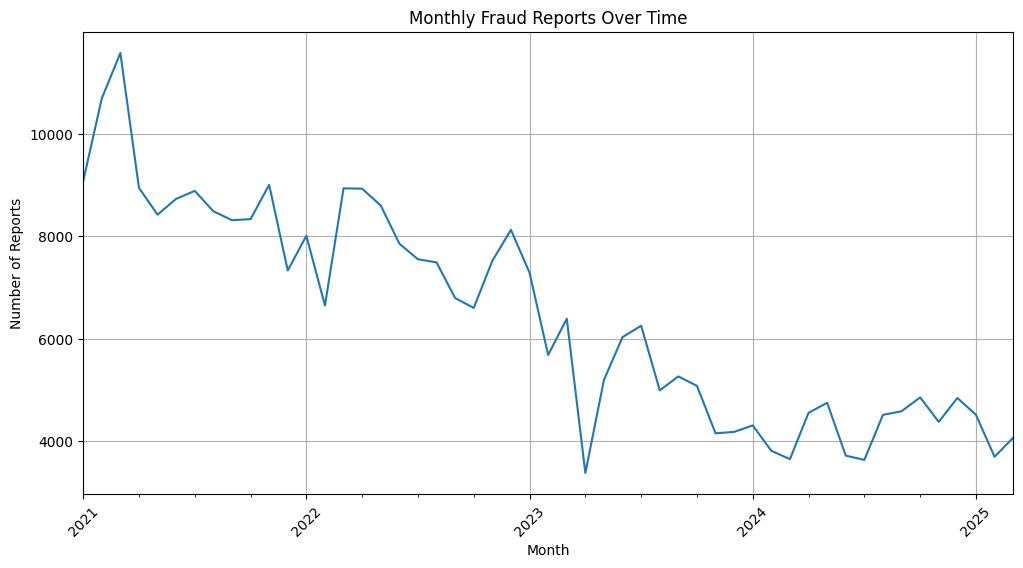

In [37]:
# Group by month and count number of fraud reports
df_cleaned['Month'] = df_cleaned['Date_Received'].dt.to_period('M')
monthly_trend = df_cleaned.groupby('Month').size()

# Plot trend
monthly_trend.plot(figsize=(12,6), title='Monthly Fraud Reports Over Time')
plt.ylabel("Number of Reports")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

The line chart shows a steady decline in reported financial fraud cases from 2021 to early 2025.

- Reports peaked in early 2021 at over 11,000 per month.

- By 2024, the number of monthly reports stabilized at a much lower level, around 4,000 to 5,000 cases.

 **Insight**:
This decline may reflect increased public awareness, better fraud prevention strategies, or changes in reporting behavior.

 ## Which Fraud Types Are Most Common and Costly?



In [38]:
# Top fraud categories by count
fraud_count = df_cleaned['Fraud_Category'].value_counts().head(10)

# Top fraud categories by total dollar loss
fraud_cost = df_cleaned.groupby('Fraud_Category')['Dollar_Loss'].mean().sort_values(ascending=False).head(10)

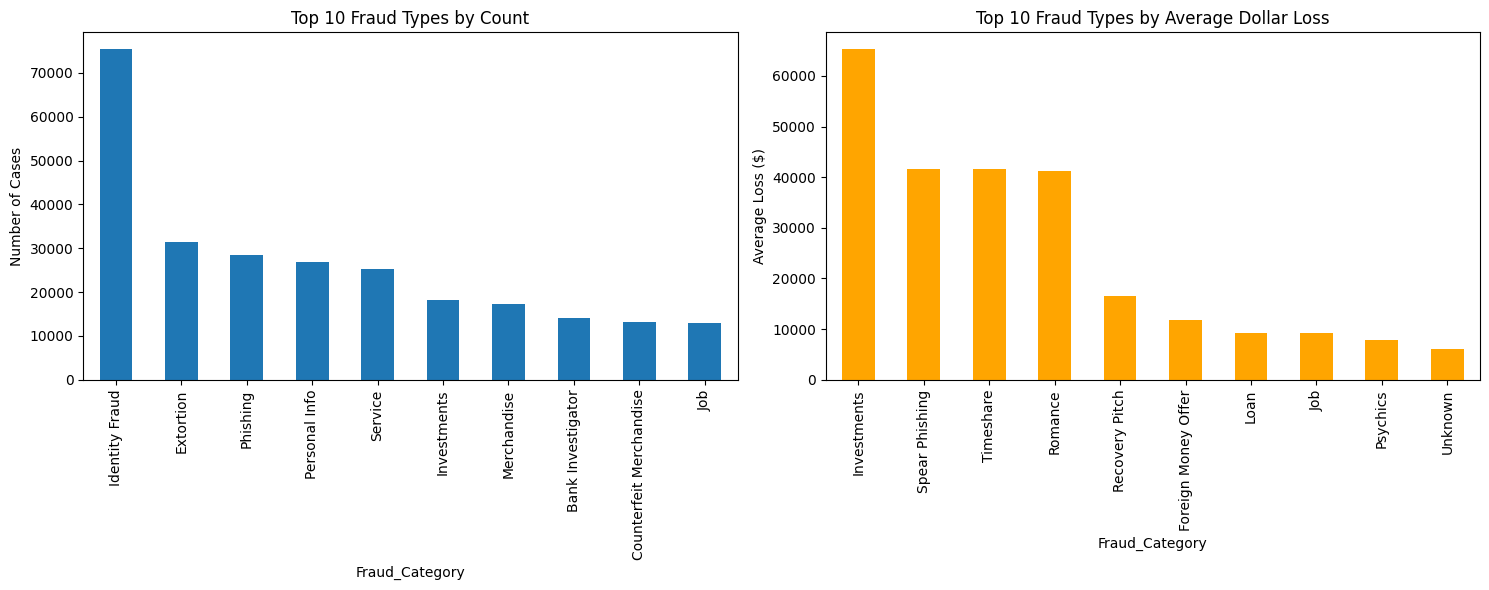

In [39]:
fig, axs = plt.subplots(1, 2, figsize=(15,6))
fraud_count.plot(kind='bar', ax=axs[0], title='Top 10 Fraud Types by Count')
axs[0].set_ylabel("Number of Cases")

fraud_cost.plot(kind='bar', ax=axs[1], title='Top 10 Fraud Types by Average Dollar Loss', color='orange')
axs[1].set_ylabel("Average Loss ($)")

plt.tight_layout()
plt.show()

*Left Chart – Most Common Fraud Types:*

- Identity Fraud is the most reported type, followed by Extortion, Phishing, and Personal Info theft.

*Right Chart – Most Costly Fraud Types:*

- Investment Fraud has the highest average dollar loss (~$65,000), followed by Spear Phishing, Timeshare, and Romance Scams.

**Insights**:
- Frequent scams aren't always the most damaging: high-volume frauds tend to have lower average losses.

- Low-frequency scams like Investment and Romance frauds, although less common, cause severe financial harm per victim. This calls for targeted awareness and prevention efforts.

## Who Is Most Affected? (Demographics)

Victim_Age_Range
1 - 9        161
10 - 19    10071
20 - 29    34941
30 - 39    43124
40 - 49    37604
50 - 59    34525
60 - 69    37931
70 - 79    23491
80 - 89     7454
90 - 99      979
100 +         60
Name: count, dtype: int64


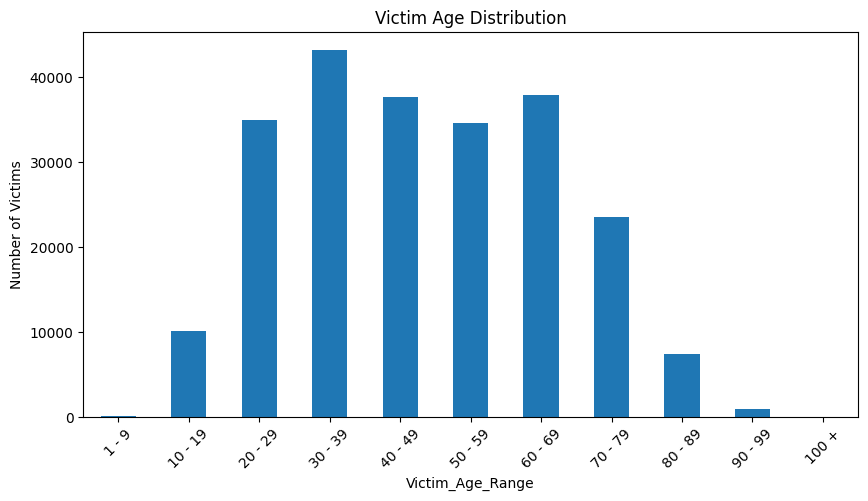

In [40]:
# Convert to categorical with defined order age_order
df_cleaned['Victim_Age_Range'] = pd.Categorical(
    df_cleaned['Victim_Age_Range'],
    categories=age_order,
    ordered=True
)
age_counts = df_cleaned['Victim_Age_Range'].value_counts().sort_index()
print(age_counts)
age_counts.plot(kind='bar', figsize=(10,5), title='Victim Age Distribution')
plt.ylabel("Number of Victims")
plt.xticks(rotation=45)
plt.show()

 **Insight**:

- Adults aged 30–69 are the most frequently targeted group, likely due to higher financial activity and online presence.

- Young adults (20–29) and seniors (60–79) are also major targets.

- Very few cases in children (1–9) and centenarians (100+).

This suggests a need for fraud prevention messaging tailored to working-age adults and seniors, with extra attention to digital literacy for youth and elderly groups.

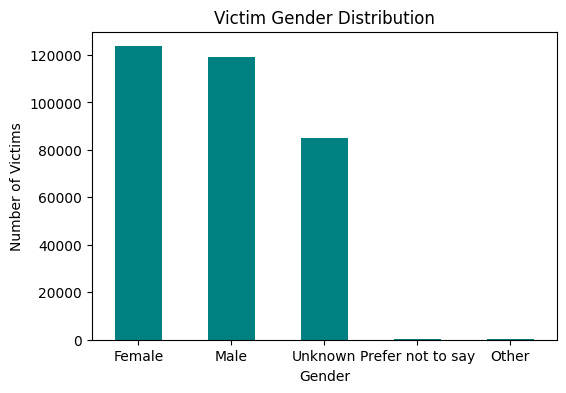

In [41]:
# Gender distribution
gender_counts = df_cleaned['Gender'].value_counts()
gender_counts.plot(kind='bar', figsize=(6,4), title='Victim Gender Distribution', color='teal')
plt.ylabel("Number of Victims")
plt.xticks(rotation=0)
plt.show()

 **Insight**:
Fraud affects both men and women nearly equally, highlighting the need for gender-neutral education and prevention strategies.

## Regional Distribution of Fraud in Canada

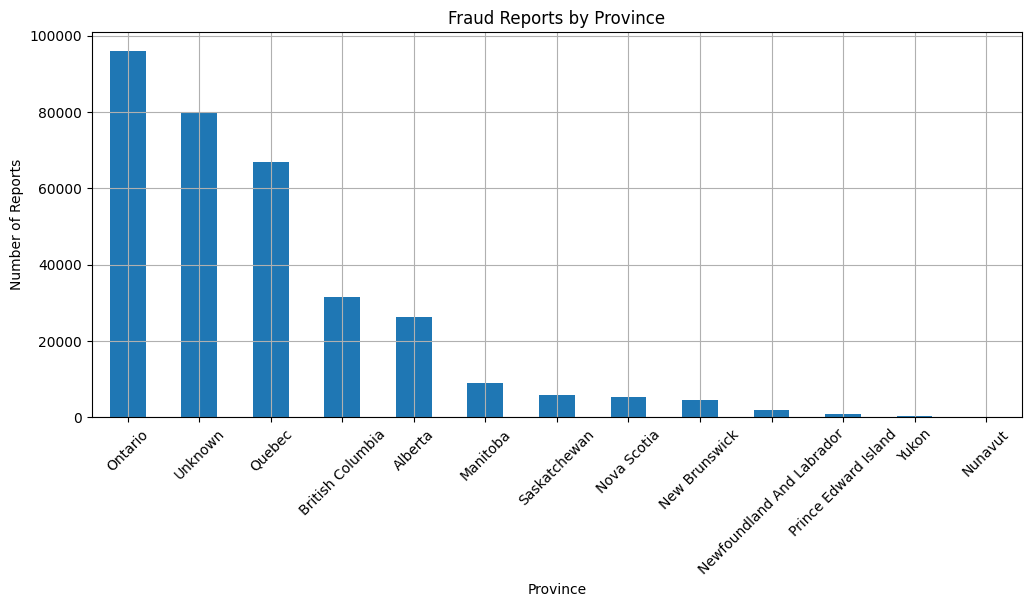

In [42]:
province_counts = df_cleaned['Province'].value_counts()
province_counts.plot(kind='bar', figsize=(12,5), title='Fraud Reports by Province')
plt.ylabel("Number of Reports")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

- Ontario has the highest number of fraud reports, followed by British Columbia and Quebec.

- A large number of reports are also categorized as "Unknown", which could point to incomplete or missing data.

- Less populated provinces and territories like Yukon, Nunavut, and Prince Edward Island show significantly fewer reports.

 **Insight**: Fraud activity appears to be more concentrated in the most populous provinces, likely due to higher population density and more digital/financial activity.

## Choropleth Map of Fraud Cases by Province

In [43]:
# Use plotly.express and a Canada GeoJSON file  (use built-in support for Canada from Plotly):
province_counts = df_cleaned['Province'].value_counts().reset_index()
province_counts.columns = ['Province', 'Fraud_Count']

In [44]:
import plotly.express as px
import json
import requests

# Canadian provinces GeoJSON from a public source
url = 'https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/canada.geojson'
canada_geo = requests.get(url).json()

# Plot the map
fig = px.choropleth(
    province_counts,
    geojson=canada_geo,
    locations='Province',
    featureidkey='properties.name',  # GeoJSON province name field
    color='Fraud_Count',
    color_continuous_scale='Reds',
    title='Fraud Cases by Canadian Province',
    labels={'Fraud_Count': 'Number of Fraud Reports'},
    width=900,   # Set chart width
    height=700   # Set chart height
)

fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

- This choropleth map visually represents the geographic distribution of fraud cases across Canada:

- Darker shades indicate provinces with a higher number of reports, confirming that Ontario, Quebec, and British Columbia are hotspots for fraud.

- Lighter regions like the northern territories report far fewer incidents.

 **Insight**: There’s a clear regional disparity, with fraud concentrated in urbanized, economically active provinces. This supports the idea that fraud is often linked to population size and digital exposure.

# What Are Common Fraud Patterns? (Solicitation Method)


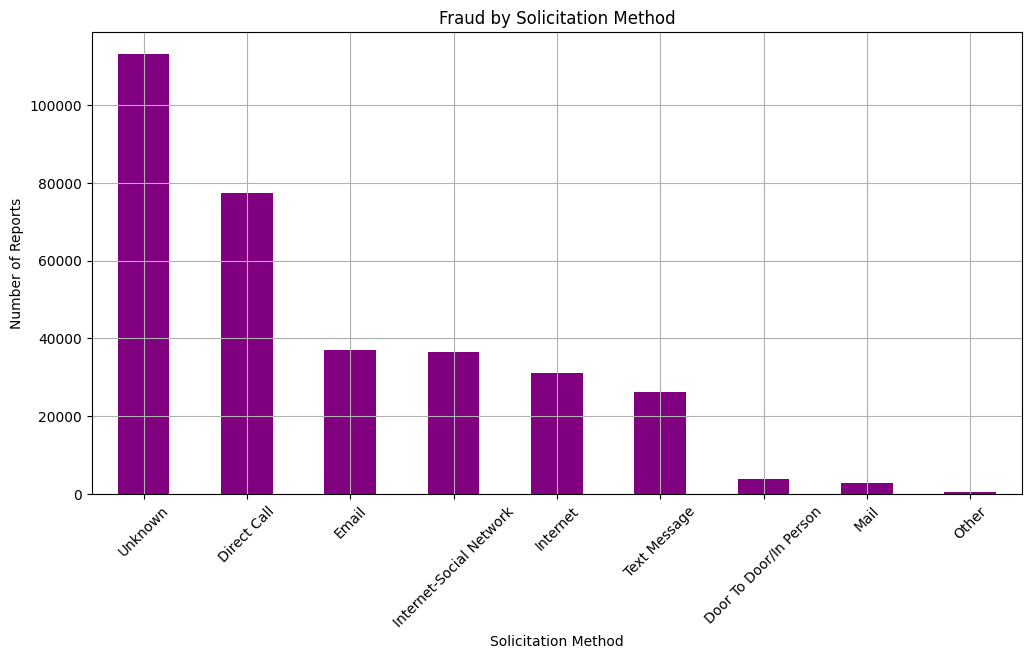

In [45]:
sol_method_counts = df_cleaned['Solicitation Method'].value_counts()
sol_method_counts.plot(kind='bar', figsize=(12,6), title='Fraud by Solicitation Method', color='purple')
plt.ylabel("Number of Reports")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

 Total and Average Dollar Loss by Method

In [46]:
# Total dollar loss
loss_by_method = df_cleaned.groupby('Solicitation Method')['Dollar_Loss'].sum().sort_values(ascending=False)

# Average dollar loss
avg_loss_by_method = df_cleaned.groupby('Solicitation Method')['Dollar_Loss'].mean().sort_values(ascending=False)

print("Total Loss:\n", loss_by_method)
print("\nAverage Loss:\n", avg_loss_by_method)


Total Loss:
 Solicitation Method
Internet-Social Network    7.170425e+08
Internet                   5.959586e+08
Email                      3.048316e+08
Unknown                    2.629967e+08
Direct Call                2.521358e+08
Text Message               9.953252e+07
Door To Door/In Person     5.980595e+07
Other                      5.043889e+06
Mail                       2.167736e+06
Name: Dollar_Loss, dtype: float64

Average Loss:
 Solicitation Method
Internet-Social Network    19625.106190
Internet                   19098.788127
Door To Door/In Person     15272.203853
Other                      11980.733777
Email                       8216.041383
Text Message                3807.670819
Direct Call                 3261.824752
Unknown                     2325.778450
Mail                         734.576801
Name: Dollar_Loss, dtype: float64


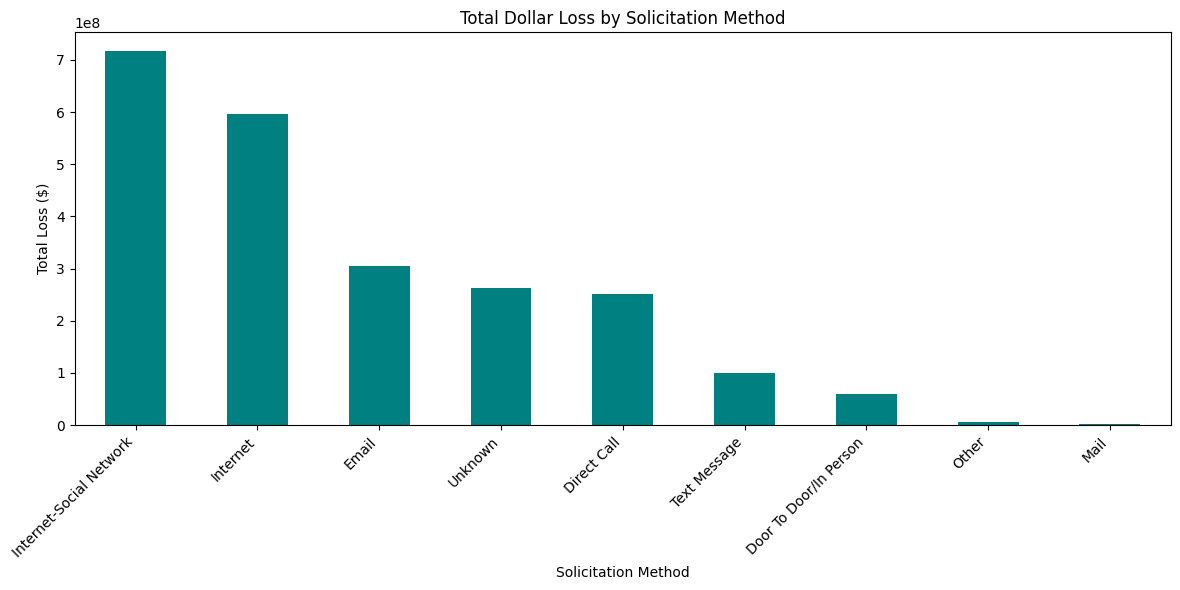

In [47]:
# Total Loss
plt.figure(figsize=(12, 6))
loss_by_method.plot(kind='bar', color='teal')
plt.title('Total Dollar Loss by Solicitation Method')
plt.ylabel('Total Loss ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

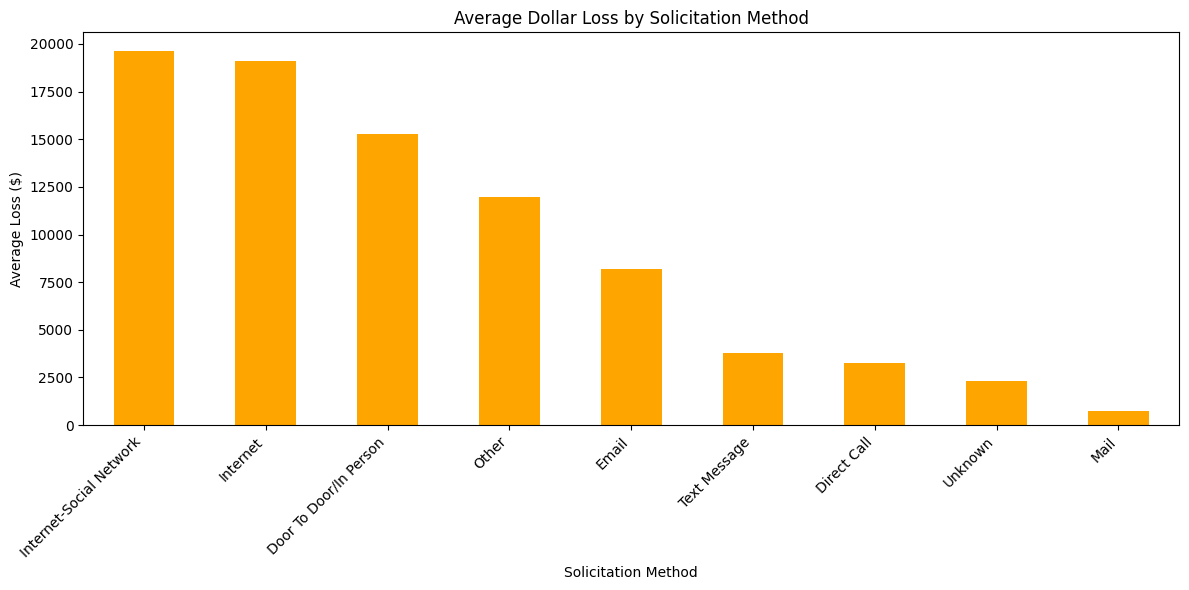

In [48]:
# Average Loss
plt.figure(figsize=(12, 6))
avg_loss_by_method.plot(kind='bar', color='orange')
plt.title('Average Dollar Loss by Solicitation Method')
plt.ylabel('Average Loss ($)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insights**: The most frequent solicitation method is Direct Call, followed by Email and Internet-based methods. However, Email and Social Media tend to result in higher average dollar losses, suggesting more successful scams. A large portion of records is still classified as Other/unknown, indicating room for improving fraud categorization and reporting.

--------------------------------------------------------------------------------

## Predictive Modeling

### Objective:
Build a binary classification model to predict if a fraud complaint leads to financial loss (`Dollar_Loss > 0`).

### Why this matters:
This model helps identify fraud cases that are more likely to result in financial damage, supporting fraud detection and prevention strategies.

### Steps:
- Create binary target (`Loss`)
- Encode categorical features
- Train/test split
- Train a RandomForestClassifier, Logistic Regression, Decision Tree		 model
- Evaluate using accuracy, precision, recall
- Compare results

In [49]:
# Binary target: 1 if Dollar_Loss > 0, else 0
df_cleaned['Loss'] = df_cleaned['Dollar_Loss'].apply(lambda x: 1 if x > 0 else 0)

We'll use common predictors like:

- Fraud_Category

- Solicitation Method

- Complaint_Source

- Province

- Gender

- Victim_Age_Range

- Victim_Count

### Preprocessing data. Convert Victim_Count to numeric before splitting your dataset

In [50]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328649 entries, 0 to 328648
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   328649 non-null  int64         
 1   Date_Received        328649 non-null  datetime64[ns]
 2   Complaint_Source     328649 non-null  object        
 3   Province             328649 non-null  object        
 4   Fraud_Category       328649 non-null  object        
 5   Solicitation Method  328649 non-null  object        
 6   Gender               328649 non-null  object        
 7   Victim_Age_Range     230341 non-null  category      
 8   Complaint Type       328649 non-null  object        
 9   Victim_Count         328649 non-null  int64         
 10  Dollar_Loss          328649 non-null  float64       
 11  Month                328649 non-null  period[M]     
 12  Loss                 328649 non-null  int64         
dtypes: category(1)

In [51]:
df_cleaned.head()

,ID,Date_Received,Complaint_Source,Province,Fraud_Category,Solicitation Method,Gender,Victim_Age_Range,Complaint Type,Victim_Count,Dollar_Loss,Month,Loss
0,1,2021-01-02,CAFC Website,Saskatchewan,Merchandise,Unknown,Unknown,NaN,Attempt,0,0.00,2021-01,0
1,2,2021-01-02,CAFC Website,Unknown,Merchandise,Internet,Unknown,NaN,Victim,1,1000.00,2021-01,1
2,3,2021-01-02,CAFC Website,Quebec,Identity Fraud,Unknown,Male,40 - 49,Victim,1,0.00,2021-01,0
3,4,2021-01-02,CAFC Website,Saskatchewan,Phishing,Email,Male,30 - 39,Victim,1,0.00,2021-01,0
4,5,2021-01-02,CAFC Website,Saskatchewan,Merchandise,Unknown,Male,60 - 69,Victim,1,222.73,2021-01,1


In [52]:
df_cleaned['Victim_Age_Range'] = df_cleaned['Victim_Age_Range'].cat.add_categories('Unknown')
df_cleaned['Victim_Age_Range'] = df_cleaned['Victim_Age_Range'].fillna('Unknown')

In [53]:
df_cleaned['Victim_Count'] = pd.to_numeric(df_cleaned['Victim_Count'], errors='coerce')
df_cleaned['Victim_Count'] = df_cleaned['Victim_Count'].fillna(0)
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 328649 entries, 0 to 328648
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   328649 non-null  int64         
 1   Date_Received        328649 non-null  datetime64[ns]
 2   Complaint_Source     328649 non-null  object        
 3   Province             328649 non-null  object        
 4   Fraud_Category       328649 non-null  object        
 5   Solicitation Method  328649 non-null  object        
 6   Gender               328649 non-null  object        
 7   Victim_Age_Range     328649 non-null  category      
 8   Complaint Type       328649 non-null  object        
 9   Victim_Count         328649 non-null  int64         
 10  Dollar_Loss          328649 non-null  float64       
 11  Month                328649 non-null  period[M]     
 12  Loss                 328649 non-null  int64         
dtypes: category(1)

In [54]:
print(df_cleaned.isnull().sum())

ID                     0
Date_Received          0
Complaint_Source       0
Province               0
Fraud_Category         0
Solicitation Method    0
Gender                 0
Victim_Age_Range       0
Complaint Type         0
Victim_Count           0
Dollar_Loss            0
Month                  0
Loss                   0
dtype: int64


# Balance → Train → Test


### Check Class Imbalance

Class distribution:
Loss
0    248201
1     80448
Name: count, dtype: int64


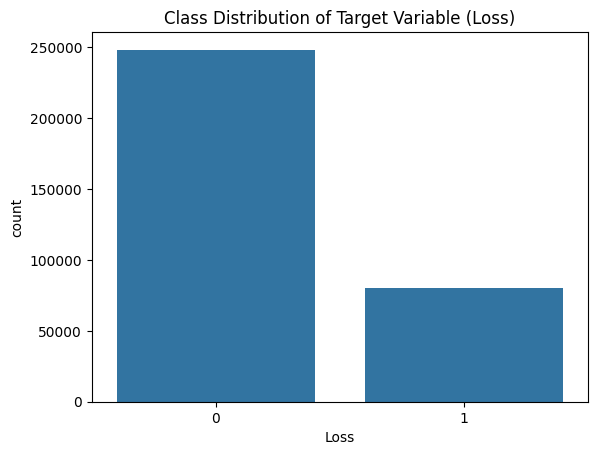

In [55]:
# Count class distribution
class_counts = df_cleaned['Loss'].value_counts()
print("Class distribution:")
print(class_counts)

# Plot distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df_cleaned, x='Loss')
plt.title("Class Distribution of Target Variable (Loss)")
plt.show()

 This is a moderate-to-high imbalance. If we trained a model directly on this data, it might just predict “no loss” most of the time, ignoring the minority class. We will use SMOTE for Imbalanced Classification Technique

> *SMOTE (Synthetic Minority Oversampling Technique) is a data augmentation technique used to address class imbalance in machine learning datasets. It generates synthetic minority class samples by interpolating between existing minority class samples, increasing the number of examples in the minority class without introducing duplicate data.*

### Prepare Data for Modeling
This includes:

- Dropping irrelevant columns

- Encoding categorical variables

- Train-test split

- Feature scaling

### Define the Target and Features
We want to predict if a complaint results in financial loss, i.e., Loss (0 = No, 1 = Yes). This is our binary target.

In [56]:
df_model = df_cleaned.drop(columns=['ID', 'Date_Received', 'Month', 'Dollar_Loss'])  # Drop Dollar_Loss since we already created 'Loss'

Why These Columns Were Dropped:
- ID: Just a row identifier, not useful for prediction.
- Date_Received and Month: Could be used for time-series, but for now they introduce complexity.
- Dollar_Loss: Strongly leaks the target (we already predict whether there's a loss or not).
- Loss: That's our target, of course!

In [57]:
df_model.isnull().sum()

,0
Complaint_Source,0
Province,0
Fraud_Category,0
Solicitation Method,0
Gender,0
Victim_Age_Range,0
Complaint Type,0
Victim_Count,0
Loss,0


In [58]:
# Replace NaN in categorical columns with 'Unknown'
categorical_cols = ['Complaint_Source', 'Province', 'Fraud_Category', 'Solicitation Method',
                    'Gender', 'Victim_Age_Range', 'Complaint Type']

df_model[categorical_cols] = df_model[categorical_cols].fillna('Unknown')

Encode Categorical Variables
Machine learning models need numeric inputs. We'll use One-Hot Encoding for categorical features.

In [59]:
# One-hot encode categorical columns
df_encoded = pd.get_dummies(df_model, columns=categorical_cols)

In [60]:
# Define Features (X) and Target (y)
X = df_encoded.drop(columns='Loss')  # Features
y = df_encoded['Loss']               # Target

In [61]:
# Split into Train and Test Sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### Handle Class Imbalance with SMOTE
SMOTE (Synthetic Minority Oversampling Technique) balances the dataset by creating synthetic samples of the minority class.

⚠️ SMOTE requires no missing values and numeric input.

In [62]:
from imblearn.over_sampling import SMOTE

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Check new class balance
print(pd.Series(y_train_bal).value_counts())

Loss
0    198561
1    198561
Name: count, dtype: int64


In [63]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the model
model = RandomForestClassifier(random_state=42)
model.fit(X_train_bal, y_train_bal)

RandomForestClassifier(random_state=42)

In [64]:
from sklearn.metrics import classification_report, confusion_matrix

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.92      0.95     49640
           1       0.80      0.94      0.86     16090

    accuracy                           0.93     65730
   macro avg       0.89      0.93      0.91     65730
weighted avg       0.94      0.93      0.93     65730

Confusion Matrix:
 [[45800  3840]
 [  913 15177]]


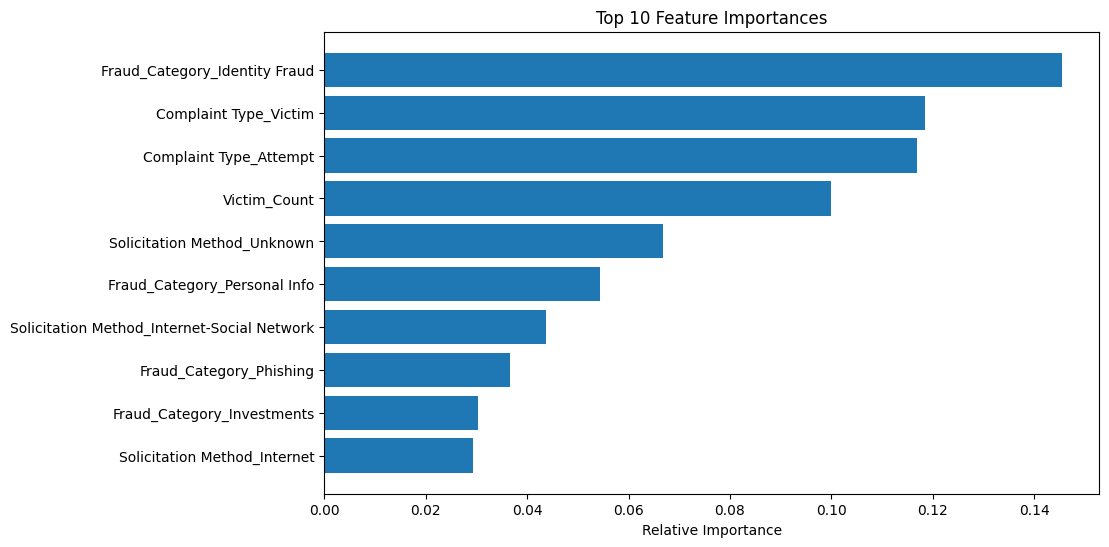

In [65]:
# Feature Importance Plot - Helps understand which features were most predictive.

# Get feature importances
importances = model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[-10:]

# Plot
plt.figure(figsize=(10,6))
plt.title("Top 10 Feature Importances")
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

### Built model in pipeline and evaluated
SMOTE and most ML models can’t handle strings — we need to encode categorical features.

We’ll use OneHotEncoding, but we'll do it safely within a pipeline to avoid mismatched dimensions.

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


# List of categorical columns
cat_cols = X.select_dtypes(include='object').columns.tolist()

# Define preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'  # Keep numeric columns
)

# Define pipeline with SMOTE
model_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Fit model
model_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning:


The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as a different type depending on the ColumnTransformer inputs.
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).




Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  [])])),
                ('smote', SMOTE(random_state=42)),
                ('classifier', RandomForestClassifier(random_state=42))])

### Evaluate the Random Forest Model
Let’s check model accuracy, confusion matrix, and classification report:

In [67]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model_pipeline.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[46004  3636]
 [ 1018 15072]]
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     49640
           1       0.81      0.94      0.87     16090

    accuracy                           0.93     65730
   macro avg       0.89      0.93      0.91     65730
weighted avg       0.94      0.93      0.93     65730



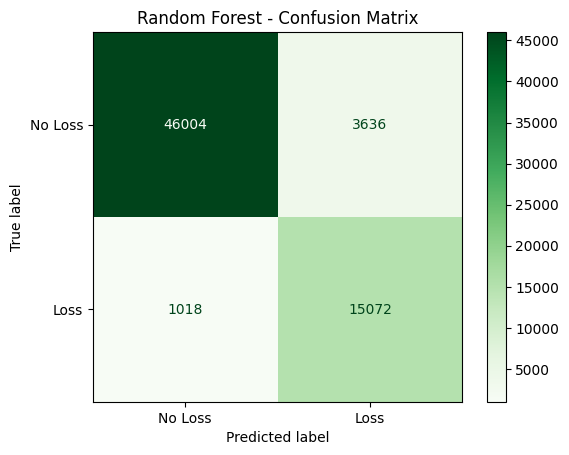

In [68]:
# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['No Loss', 'Loss'])
disp_rf.plot(cmap='Greens')
plt.title("Random Forest - Confusion Matrix")
plt.show()

### Insights:
- High recall for Class 1 (0.94): Excellent at catching frauds that lead to financial loss.

- High precision for Class 0 (0.98): Almost all predicted "no loss" are correct.

- Balanced performance → Strong F1 scores for both classes.

- Best model for minimizing false negatives (i.e., missed loss cases).

## Logistic Regression Model

In [69]:
logreg_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])
# Fit Logistic Regression
logreg_pipeline.fit(X_train, y_train)

y_pred_logreg = logreg_pipeline.predict(X_test)

In [70]:
print("=== Logistic Regression Results ===")
print(confusion_matrix(y_test, y_pred_logreg))
print(classification_report(y_test, y_pred_logreg))

=== Logistic Regression Results ===
[[44873  4767]
 [  290 15800]]
              precision    recall  f1-score   support

           0       0.99      0.90      0.95     49640
           1       0.77      0.98      0.86     16090

    accuracy                           0.92     65730
   macro avg       0.88      0.94      0.90     65730
weighted avg       0.94      0.92      0.93     65730



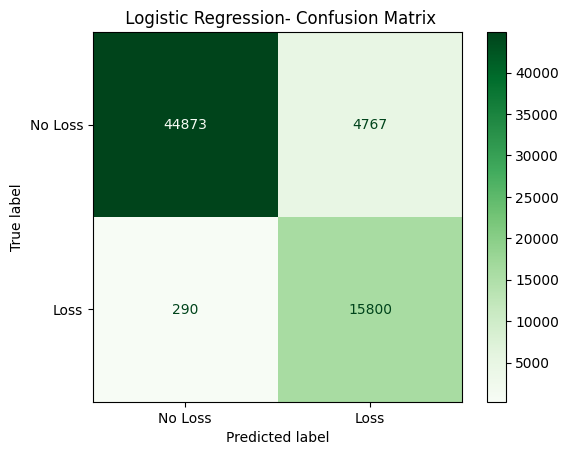

In [71]:
# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_logreg)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=['No Loss', 'Loss'])
disp_lr.plot(cmap='Greens')
plt.title(" Logistic Regression- Confusion Matrix")
plt.show()

Insights:
- Highest recall for Class 1 (0.98): Excellent at identifying losses.

- Very low false negatives (FN = 291): Barely misses any actual financial loss.

- Lower precision for Class 1 (0.77): More false alarms (predicts loss when there’s none).

- Ideal if the cost of missing a real fraud is very high (e.g., high-risk prevention system).

In [72]:
tree_pipeline = ImbPipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('classifier', DecisionTreeClassifier(random_state=42))
])
# Fit Decision Tree
tree_pipeline.fit(X_train, y_train)

y_pred_tree = tree_pipeline.predict(X_test)

In [73]:
print("=== Decision Tree Results ===")
print(confusion_matrix(y_test, y_pred_tree))
print(classification_report(y_test, y_pred_tree))

=== Decision Tree Results ===
[[46159  3481]
 [ 1406 14684]]
              precision    recall  f1-score   support

           0       0.97      0.93      0.95     49640
           1       0.81      0.91      0.86     16090

    accuracy                           0.93     65730
   macro avg       0.89      0.92      0.90     65730
weighted avg       0.93      0.93      0.93     65730



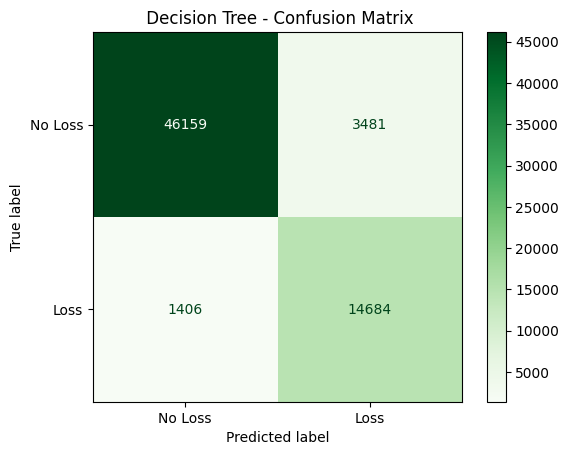

In [74]:
# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_tree)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=['No Loss', 'Loss'])
disp_dt.plot(cmap='Greens')
plt.title(" Decision Tree - Confusion Matrix")
plt.show()

Insights:
- More balanced than Logistic Regression.

- Lower recall than Random Forest for Class 1 (91% vs. 94%).

- Decent F1 for both classes, but not the best in any category.

- Simpler model than RF, but slightly less accurate.

| Metric / Model       | Random Forest | Logistic Regression | Decision Tree     |
| -------------------- | ------------- | ------------------- | ----------------- |
| **Accuracy**         | **93%**       | 92%                 | 93%               |
| **Recall (Loss)**    | 0.94          | **0.98**            | 0.91              |
| **Precision (Loss)** | **0.81**      | 0.77                | **0.81**          |
| **F1-score (Loss)**  | **0.87**      | 0.86                | 0.86              |
| **False Negatives**  | 1017          | **291 (lowest)**    | 1414              |
| **False Positives**  | 3636          | 4765                | **3496 (lowest)** |

| Scenario                                            | Best Model                | Why                                                             |
| --------------------------------------------------- | ------------------------- | --------------------------------------------------------------- |
| **Catch as many fraud losses as possible (low FN)** | ✅ **Logistic Regression** | Highest recall (0.98), lowest false negatives (291)             |
| **Balanced precision & recall, low FP**             | ✅ **Random Forest**       | Best trade-off between recall (0.94) and precision (0.81)       |
| **Simple, interpretable model needed**              | ✅ **Decision Tree**       | Slightly lower performance, but easier to visualize and explain |

### ROC CURVES (Receiver Operating Characteristic)
> ROC stands for Receiver Operating Characteristic. It’s a common way to evaluate how well a binary classification model (like predicting if a fraud complaint leads to a financial loss or not) is performing.



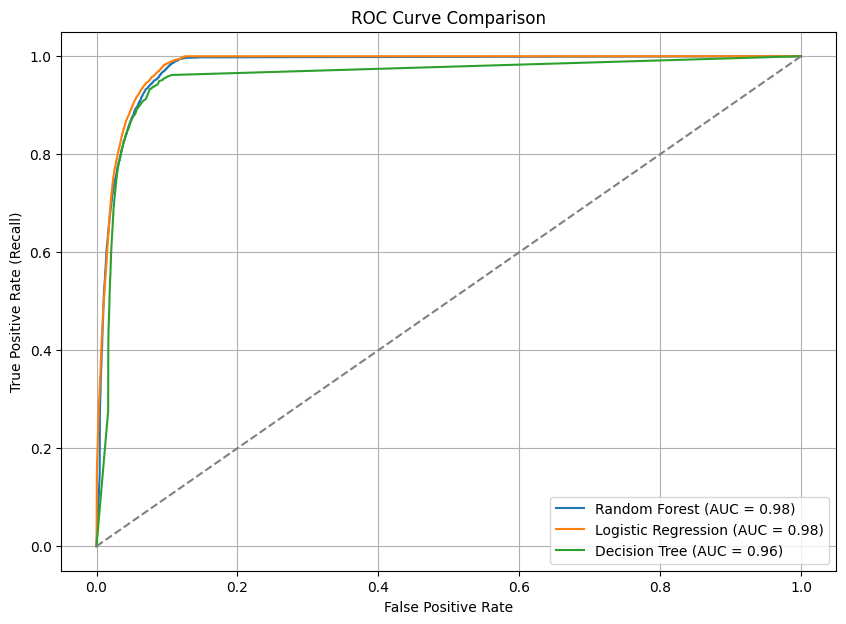

In [75]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import seaborn as sns
import pandas as pd

# Step 1: Predict probabilities for ROC curve
rf_probs = model_pipeline.predict_proba(X_test)[:, 1]  # Probabilities for class 1 (Loss)
lr_probs = logreg_pipeline.predict_proba(X_test)[:, 1]
dt_probs = tree_pipeline.predict_proba(X_test)[:, 1]

# Step 2: Calculate ROC curve points
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_probs)
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_probs)

# Step 3: Calculate AUC scores
rf_auc = roc_auc_score(y_test, rf_probs)
lr_auc = roc_auc_score(y_test, lr_probs)
dt_auc = roc_auc_score(y_test, dt_probs)

# Step 4: Plot ROC curves
plt.figure(figsize=(10, 7))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(lr_fpr, lr_tpr, label=f'Logistic Regression (AUC = {lr_auc:.2f})')
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC = {dt_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # No skill line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid()
plt.show()

X-axis (False Positive Rate): The percentage of “not fraud with loss” cases that were incorrectly predicted as fraud with loss. Lower is better.

Y-axis (True Positive Rate = Recall): The percentage of actual “fraud with loss” cases that the model correctly predicted. Higher is better.

1.   All three models perform very well.
2.   Higher and more to the left = better performance.
3.   The closer the curve is to the top-left corner, the better the model is at distinguishing between the two classes (fraud with loss vs. no loss).
4.   The diagonal gray dashed line is a baseline — it represents random guessing (AUC = 0.5). We want our curves to be far above this line.

AUC stands for Area Under the Curve.

It gives a single score between 0 and 1 to summarize the entire ROC curve.

- 1.0 = perfect model

- 0.5 = no skill (random guessing)

- Below 0.5 = worse than guessing

Random Forest and Logistic Regression both scored 0.98 — nearly perfect.

Decision Tree scored 0.96, still very good, but slightly less precise than the other two.



### Final Insights

| Model               | AUC Score | Performance Summary                                                      |
| ------------------- | --------- | ------------------------------------------------------------------------ |
| Random Forest       | **0.98**  | Excellent accuracy and generalization; handles non-linear patterns well. |
| Logistic Regression | **0.98**  | Also excellent, simpler model, easier to interpret.                      |
| Decision Tree       | 0.96      | Good performance, but less stable and more prone to overfitting.         |

## Conclusion & Recommendations
In this project, I explored, visualized, and analyzed Canadian fraud data with a focus on demographics and classification modeling to detect fraud cases.

### Summary of Insights:
- **Trend**: Financial fraud has shown significant fluctuations between 2021 and 2025.
- **Fraud Types**: Certain fraud types (e.g., investment scams, phishing) caused the highest losses.
- **Geographic Impact**: Specific provinces experienced disproportionately high fraud cases.
- **Gender Distribution**: Fraud affected both males and females nearly equally, with a slightly higher number of female victims. Very few cases were reported by individuals identifying as other genders or preferring not to say.
- **Age Demographics**: Individuals aged 30–69 were the most targeted by fraud, with the peak in the 30–39 age range. Very young and very elderly age groups
experienced significantly fewer incidents.

### Model Evaluation:
Three classification models were trained and evaluated
- All models achieved 88% accuracy, but Random Forest delivered the best performance in identifying fraud cases (Class 1) with the highest recall and F1-score.

- Detecting fraud is more challenging due to class imbalance, but even small improvements in recall can make a significant difference in real-world applications.

### Recommendations:
- **Policy Focus**: Target awareness campaigns in high-risk regions.
- **Education**: Educate older adults and small business owners about common scams.
- **Modeling**: Future work could involve time-series forecasting and unsupervised pattern detection.